### Types of Feature Selection Methods

| Category         | Technique                                    |
| ---------------- | -------------------------------------------- |
| Filter Methods   | Correlation, Variance Threshold              |
| Wrapper Methods  | Forward Selection, Backward Elimination, RFE |
| Embedded Methods | Lasso Regression                             |


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url)
df = df.drop("Unnamed: 0",axis=1)
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
X = df[['TV','radio','newspaper']]
y = df['sales']

### Filter Method 1 — Correlation Based Selection

Remove features that **do not correlate with the target.**

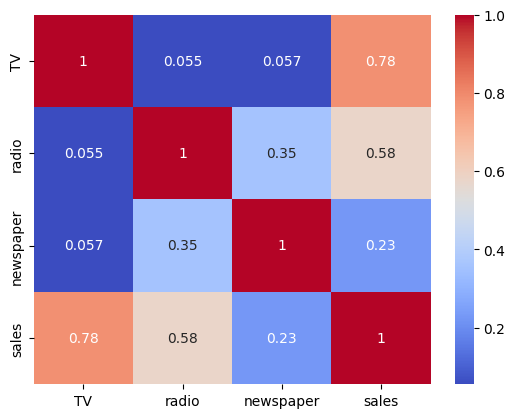

In [7]:
corr = df.corr()

sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

`TV → high correlation`
`Radio → medium`
`Newspaper → very low`

- Newspaper may be removed

In [8]:
# Feature selection
selected_features = corr['sales'][abs(corr['sales']) > 0.1].index
print(selected_features)

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')


#### Note :  Filter methods are fast but ignore feature interactions.

### Filter Method 2 — Variance Threshold

- In case we have many features in our dataset. we have to discord some features to avoid course of dimentionality and to improve the accuracy.
- Varience Threshold is there to remove features having almost same features or rather with lower varience then threshold.
  
Remove features with **very low variance.**

Low variance means the feature hardly changes.

In [19]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_var = selector.fit_transform(X)

print(X_var.shape)

(200, 3)


In [20]:
selector.get_support()

array([ True,  True,  True])

### Forward Selection
Start with no features and add features one by one.

1. Step1: try each feature individually
2. Step2: select best feature
3. Step3: add another feature
4. Step4: repeat until no improvement

In [24]:
import statsmodels.api as sm

remaining = list(X.columns)
selected = []

current_score = 0
best_new_score = 0

while remaining:

    scores_with_candidates = []

    for candidate in remaining:

        features = selected + [candidate]

        X_train = sm.add_constant(X[features])

        model = sm.OLS(y, X_train).fit()

        score = model.rsquared

        scores_with_candidates.append((score, candidate))

    scores_with_candidates.sort()

    best_new_score, best_candidate = scores_with_candidates[-1]

    # stopping condition
    if best_new_score > current_score:
        remaining.remove(best_candidate)
        selected.append(best_candidate)
        current_score = best_new_score

        print("Added:", best_candidate,"<==>", "R2:", best_new_score)

    else:
        break

print("Final Selected Features:", selected)

Added: TV <==> R2: 0.611875050850071
Added: radio <==> R2: 0.8971942610828956
Added: newspaper <==> R2: 0.8972106381789522
Final Selected Features: ['TV', 'radio', 'newspaper']


### Backward Elimination (Very Popular)

Start with all features and **remove least useful features.**

Use p-value.

Rule:

**`p-value > 0.05 → remove feature`**

In [17]:
import statsmodels.api as sm

X_be = sm.add_constant(X)

model = sm.OLS(y,X_be).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Sat, 09 May 2026   Prob (F-statistic):           1.58e-96
Time:                        11:43:24   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

## Recursive Feature Elimination (RFE)
- Train model repeatedly and remove weakest feature each time.

In [18]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model = LinearRegression()

rfe = RFE(model,n_features_to_select=2)

X_rfe = rfe.fit_transform(X,y)

print(rfe.support_)
print(rfe.ranking_)

[ True  True False]
[1 1 2]


In [24]:
rfe.ranking_

array([1, 1, 2])

In [31]:
from sklearn.feature_selection import RFECV
rfecv = RFECV(estimator=model, step=1, cv=5)
print("Optimal no of features : ",rfecv.n_features_)
print("Best Features : ",df.columns[rfecv.support_])

AttributeError: 'RFECV' object has no attribute 'n_features_'

## Lasso Regression

Technique using **regularization.**

Algorithm automatically **shrinks useless coefficients to zero.**

In [19]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X,y)

coeff = pd.Series(lasso.coef_,index=X.columns)

print(coeff)

TV           0.045752
radio        0.187887
newspaper   -0.000668
dtype: float64


If coefficient becomes 0

That feature is automatically removed.

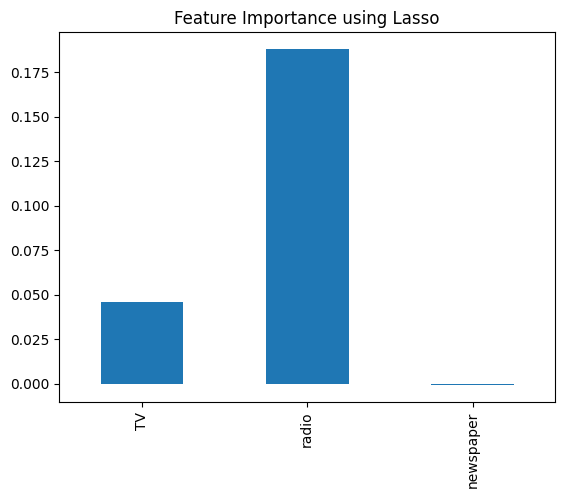

In [20]:
coeff.plot(kind="bar")

plt.title("Feature Importance using Lasso")

plt.show()

## Final Comparison Table

| Method               | Speed     | Accuracy  | Uses Model |
| -------------------- | --------- | --------- | ---------- |
| Correlation          | Very Fast | Low       | No         |
| Variance Threshold   | Very Fast | Low       | No         |
| Forward Selection    | Medium    | Good      | Yes        |
| Backward Elimination | Medium    | Good      | Yes        |
| RFE                  | Slow      | Very Good | Yes        |
| Lasso                | Fast      | Very Good | Yes        |
